In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.graph_objects as go
from ipywidgets import *
import ipympl
from scipy import stats

In [2]:
# Plots
def get_circle(r, z):
    x = np.cos(np.linspace(0, 2*np.pi, 100)) * r
    y = np.sin(np.linspace(0, 2*np.pi, 100)) * r
    z = np.ones(shape=100) * z
    return x,y,z

def plot_molecular_density_volume(trajectories, grid_size=25, title="Molecular Density Distribution", axis_range=(-100,100)):
    """
    Create a 3D volume plot of molecular density aggregated over time.
    
    Parameters:
    trajectories: numpy array of shape (n, 3, t) where:
        n: number of molecules
        3: x, y, z coordinates
        t: number of timepoints
    grid_size: number of bins in each dimension
    
    Returns:
    plotly.graph_objects.Figure
    """
    # Reshape the array to get all positions across time and molecules
    # New shape will be (n*t, 3)
    all_positions = trajectories.transpose(0, 2, 1).reshape(-1, 3)
    
    # Find the bounds of the data
    mins = np.min(all_positions, axis=0)
    maxs = np.max(all_positions, axis=0)
    
    # Create the grid
    x_grid = np.linspace(mins[0], maxs[0], grid_size)
    y_grid = np.linspace(mins[1], maxs[1], grid_size)
    z_grid = np.linspace(mins[2], maxs[2], grid_size)
    X, Y, Z = np.meshgrid(x_grid, y_grid, z_grid, indexing='ij')
    
    # Calculate the density using gaussian_kde
    positions = np.vstack([all_positions[:, 0], all_positions[:, 1], all_positions[:, 2]])
    kernel = stats.gaussian_kde(positions)
    
    # Evaluate the density on the grid
    positions_grid = np.vstack([X.ravel(), Y.ravel(), Z.ravel()])
    density = kernel(positions_grid)
    density = density.reshape(X.shape)
    
    # Normalize density to 0-1 range
    density = (density - density.min()) / (density.max() - density.min())
    
    # Create the volume plot
    fig = go.Figure(data=go.Volume(
        x=X.flatten(),
        y=Y.flatten(),
        z=Z.flatten(),
        value=density.flatten(),
        isomin=0.1,
        isomax=0.8,
        opacity=0.1,
        surface_count=17,
        colorscale='Viridis',  # You can change this to any plotly colorscale
        caps=dict(x_show=False, y_show=False, z_show=False)  # Hide the caps
    ))
    
    circles = [(54, 15), (54, -15), (39, 0)]
    for (r,z) in circles:
        x,y,z = get_circle(r,z)
        fig.add_trace(
            go.Scatter3d(
                x=x, y=y, z=z,
                mode='lines',
                opacity=0.5,
                line=dict(width=2, color="black"),
                showlegend=False
            )
        )
        
    # Update the layout
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis=dict(range=[axis_range[0], axis_range[1]]),
            yaxis=dict(range=[axis_range[0], axis_range[1]]),
            zaxis=dict(range=[axis_range[0], axis_range[1]]),
            aspectmode='cube'  # This ensures equal aspect ratio
        ),
        width=800,
        height=800
    )
    fig.show()
    return fig

def visualize_trajectories_3d_mpl(trajectories, as_list=False, alpha=0.1, title="", axis_range=(-100,100)):
    # trajectories should be a numpy array of shape [n_trajs, 3, n_steps]
    # if as_list, trajectories should be an array of len(n_trajs) of numpy array of shape [3, n_steps]
    # mpl.rcParams['axes3d.mouserotationstyle'] = 'trackball'  # 'azel', 'trackball', 'sphere', or 'arcball'
    ax = plt.figure().add_subplot(projection='3d')
    n_trajs = len(trajectories)
    for i in range(n_trajs):
        if as_list:
            x = trajectories[i][0, :]
            y = trajectories[i][1, :]
            z = trajectories[i][2, :]
        else:
            x = trajectories[i, 0, :]
            y = trajectories[i, 1, :] 
            z = trajectories[i, 2, :] 
        # alpha_norm_factor = 1 if normalize is False else 2 * np.pi * x
        plt.plot(x, y, z, alpha=alpha)
    # ax.set_aspect('equal', adjustable='box')
    plt.title(title)
    ax.set_xlim(axis_range[0], axis_range[1])
    ax.set_ylim(axis_range[0], axis_range[1])
    ax.set_zlim(axis_range[0], axis_range[1])
    plt.show()
    
    
def visualize_trajectories_3d_plotly(trajectories, as_list=False, alpha=0.1, title="", axis_range=(-100,100)):
    # trajectories should be a numpy array of shape [n_trajs, 3, n_steps]
    # if as_list, trajectories should be an array of len(n_trajs) of numpy array of shape [3, n_steps]
    
    fig = go.Figure()
    circles = [(54, 15), (54, -15), (39, 0)]
    for (r,z) in circles:
        x,y,z = get_circle(r,z)
        fig.add_trace(
            go.Scatter3d(
                x=x, y=y, z=z,
                mode='lines',
                opacity=0.5,
                line=dict(width=2, color="black"),
                showlegend=False
            )
        )
    
    n_trajs = len(trajectories)
    for i in range(n_trajs):
        if as_list:
            x = trajectories[i][0, :]
            y = trajectories[i][1, :]
            z = trajectories[i][2, :]
        else:
            x = trajectories[i, 0, :]
            y = trajectories[i, 1, :]
            z = trajectories[i, 2, :]
        # Add each trajectory as a 3D line
        fig.add_trace(
            go.Scatter3d(
                x=x, y=y, z=z,
                mode='lines',
                opacity=alpha,
                line=dict(width=2),
                showlegend=False
            )
        )
    # Update layout for equal aspect ratio and axis ranges
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis=dict(range=[axis_range[0], axis_range[1]]),
            yaxis=dict(range=[axis_range[0], axis_range[1]]),
            zaxis=dict(range=[axis_range[0], axis_range[1]]),
            aspectmode='cube'  # This ensures equal aspect ratio
        ),
        width=800,
        height=800
    )
    fig.show()
    return fig

def visualize_trajectories(trajectories, as_list=False, alpha=0.1, title="", axis_range=(-100,100)):
    # trajectories should be a numpy array of shape [n_trajs, 3, n_steps]
    # if as_list, trajectories should be an array of len(n_trajs) of numpy array of shape [3, n_steps]
    n_trajs = len(trajectories)
    for i in range(n_trajs):
        if as_list:
            x = trajectories[i][1, :]
            y = trajectories[i][2, :]
        else:
            x = trajectories[i, 1, :]
            y = trajectories[i, 2, :] 
        # alpha_norm_factor = 1 if normalize is False else 2 * np.pi * x
        plt.plot(x, y, alpha=alpha)
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.title(title)
    plt.xlim(axis_range[0], axis_range[1])
    plt.ylim(axis_range[0], axis_range[1])
    plt.show()

In [5]:
# Data processsing
def calc_limited_trajectories(trajectories, min_val, max_val, axis):
    # creates a list only of subtrajectories that are within range in the axis
    new_trajs = []
    n_trajs, _, n_steps = trajectories.shape
    for i in range(n_trajs):
        traj = []
        for j in range(n_steps):
            coords = trajectories[i, :, j]
            if coords[axis] < min_val or coords[axis] > max_val:
                if traj != []:
                    new_trajs.append(np.vstack(traj).T)
                    traj = []
                continue
            traj.append(coords)
        if traj != []:
            new_trajs.append(np.vstack(traj).T)
    return new_trajs
    
def calc_radial_dist_trajectories(trajectories):
    new_trajs = np.zeros_like(trajectories)
    n_trajs, _, n_steps = trajectories.shape
    new_trajs[:, 2, :] = trajectories[:, 2, :]
    new_trajs[:, 1, :] = np.sqrt(trajectories[:, 0, :] ** 2 + trajectories[:, 1, :] ** 2)
    return new_trajs

def align_trajectories(trajectories, lock_to_eights=False, only_in_pore=True, target_angle=0):
    """
    Align molecular trajectories to have the same average angle on the xy plane.
    
    Args:
        trajectories: numpy array of shape (n, 3, t) where:
            n: number of molecules
            3: x, y, z coordinates
            t: number of timepoints
    
    Returns:
        aligned_trajectories: numpy array of same shape as input, with aligned trajectories
    """
    n, _, t = trajectories.shape
    aligned_trajectories = np.zeros_like(trajectories)
    
    # Calculate average angles for each trajectory
    avg_angles = np.zeros(n)
    for i in range(n):
        if only_in_pore:
            mask = (trajectories[i, 2, :] <= 15) & (trajectories[i, 2, :] >= -15)# Only account for positions inside the pore 
            xy_coords = trajectories[i, :2, mask].T  # Get x,y coordinates
        else:
            xy_coords = trajectories[i, :2, :]  # Get x,y coordinates
        angles = np.arctan2(xy_coords[1, :], xy_coords[0, :])  # Calculate angles
        angles = np.unwrap(angles)
        avg_angles[i] = np.mean(angles)
    
    # Calculate rotation angles needed to align trajectories
    rotation_angles = target_angle - avg_angles
    if lock_to_eights:
        eighth = (np.pi / 4)
        rotation_angles =  np.round(rotation_angles / eighth) * eighth
        
    
    # Apply rotations
    for i in range(n):
        # Create rotation matrix for xy plane
        cos_theta = np.cos(rotation_angles[i])
        sin_theta = np.sin(rotation_angles[i])
        rotation_matrix = np.array([
            [cos_theta, -sin_theta, 0],
            [sin_theta, cos_theta, 0],
            [0, 0, 1]
        ])
        
        # Apply rotation to each timepoint
        aligned_trajectories[i, :, :] = np.dot(rotation_matrix, trajectories[i, :, :])
    
    return aligned_trajectories

    

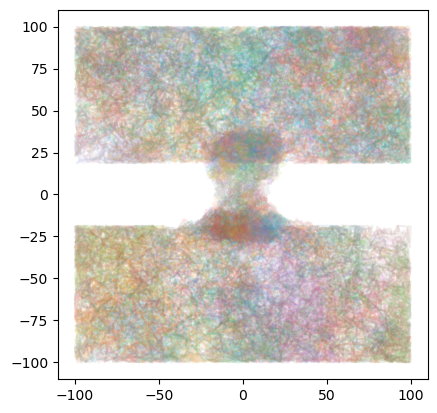

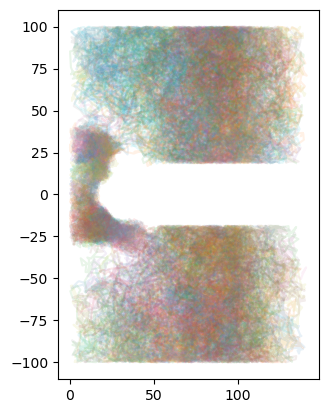

In [23]:
with open("data/spatial_markov_chain_data.pickle", "rb") as f:
    trajectories = pickle.load(f)
visualize_trajectories(trajectories)
# new_trajs = calc_limited_trajectories(trajectories, 40, 50, 0)
# visualizse_trajectories(new_trajs)
new_trajs = calc_radial_dist_trajectories(trajectories)
visualize_trajectories(new_trajs, as_list=False)

In [3]:
# %matplotlib widget

with open(f"data/merged/110-140.pickle", "rb") as f:
    trajectories = pickle.load(f)
rng = np.random.default_rng()
sample_trajs = rng.choice(trajectories, size=50, replace=False, axis=0, shuffle=True)

passed = [60, 269, 438, 512, 654, 810, 948, 1020, 1220, 2627, 2965, 3042, 3357, 3819, 3910, 4404, 4605, 4682, 4706, 4834, 5096, 5186, 5219, 5761, 5888, 5916, 5966, 6134, 6385, 6608, 6688, 6867, 6943, 7432, 7572, 7849, 7863, 7870, 7880, 7953, 8063, 8078, 8087, 8107, 8425, 8426, 8553, 8575, 8617, 8753, 9632, 9654, 10011, 10390, 10403, 10590, 10656, 10791, 10971, 11166, 11173, 11234, 11317]
passed_trajs = trajectories[passed]

# fig = visualize_trajectories_3d_plotly(passed_trajs, alpha=0.7, title="10 transport trajectories (from 50 diverged sims - 20 us each)", axis_range=[-50, 50])
# fig.write_html("trajectories.html")

# fig = visualize_trajectories_3d_plotly(align_trajectories(passed_trajs), alpha=0.7, title="10 transport trajectories (from 50 diverged sims - 20 us each)", axis_range=[-50, 50])


# fig = visualize_trajectories_3d_plotly(align_trajectories(passed_trajs, lock_to_eights=True), alpha=0.7, title="10 transport trajectories (from 50 diverged sims - 20 us each)", axis_range=[-50, 50])
# fig.write_html("aligned_trajectories.html")

# visualize_trajectories(sample_trajs, alpha=0.5, title="50 random paths", axis_range=[-50, 50])
# visualize_trajectories(trajectories, alpha=0.1)
# new_trajs = calc_radial_dist_trajectories(trajectories)
# visualize_trajectories(new_trajs, as_list=False, alpha=0.1, title="By radial distance (not normalized)")


In [12]:
# fig = plot_molecular_density_volume(passed_trajs)
fig = plot_molecular_density_volume(align_trajectories(passed_trajs, lock_to_eights=True, only_in_pore=False), axis_range=[-50, 50], title="Molecular Density, Aligned Transported NTRs")
sample_trajs = np.random.default_rng().choice(trajectories, size=200, replace=False, axis=0, shuffle=True,)
fig = plot_molecular_density_volume(align_trajectories(sample_trajs, lock_to_eights=True, only_in_pore=False), axis_range=[-50, 50], title="Molecular Density, Aligned All NTRs")